In [2]:
from pathlib import Path
import json
import joblib
import numpy as np
from PIL import Image

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "phone_detection" / "split"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

SAVE_DIR = PROJECT_ROOT / "models" / "phone_detection_ml"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = SAVE_DIR / "random_forest_phone_detection.pkl"
CLASS_NAMES_PATH = SAVE_DIR / "class_names.json"
CONFUSION_MATRIX_PATH = SAVE_DIR / "confusion_matrix_random_forest.png"

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Train exists:", TRAIN_DIR.exists())
print("Val exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())
print("Save dir:", SAVE_DIR)

Project root: C:\Users\user\Desktop\Smartphone_AI_Project
Data dir: C:\Users\user\Desktop\Smartphone_AI_Project\data\phone_detection\split
Train exists: True
Val exists: True
Test exists: True
Save dir: C:\Users\user\Desktop\Smartphone_AI_Project\models\phone_detection_ml


In [4]:
IMAGE_SIZE = (64, 64)

CLASS_NAMES = ["multiple_phones", "no_phone", "phone"]

print("Classes:", CLASS_NAMES)

Classes: ['multiple_phones', 'no_phone', 'phone']


In [5]:
for split_name, split_dir in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    print("\n", split_name.upper())
    
    for class_name in CLASS_NAMES:
        class_dir = split_dir / class_name
        
        if class_dir.exists():
            image_count = len(list(class_dir.glob("*.*")))
            print(class_name, ":", image_count)
        else:
            print(class_name, ": folder not found")


 TRAIN
multiple_phones : 349
no_phone : 390
phone : 959

 VAL
multiple_phones : 75
no_phone : 83
phone : 205

 TEST
multiple_phones : 75
no_phone : 84
phone : 206


In [6]:
def preprocess_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize(IMAGE_SIZE)

    image_array = np.array(image) / 255.0

    image_flattened = image_array.flatten()

    return image_flattened

In [7]:
def load_dataset(folder_path):
    X = []
    y = []

    for label_index, class_name in enumerate(CLASS_NAMES):
        class_folder = folder_path / class_name

        print("Reading:", class_folder)

        if not class_folder.exists():
            print("Folder not found:", class_folder)
            continue

        image_files = list(class_folder.glob("*.*"))

        for image_path in image_files:
            try:
                features = preprocess_image(image_path)
                X.append(features)
                y.append(label_index)
            except Exception as e:
                print("Skipping corrupted image:", image_path)
                print("Error:", e)

    X = np.array(X)
    y = np.array(y)

    return X, y

In [8]:
X_train, y_train = load_dataset(TRAIN_DIR)
X_val, y_val = load_dataset(VAL_DIR)
X_test, y_test = load_dataset(TEST_DIR)

print("\nDataset shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Reading: C:\Users\user\Desktop\Smartphone_AI_Project\data\phone_detection\split\train\multiple_phones


C:\Users\user\anaconda3\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Reading: C:\Users\user\Desktop\Smartphone_AI_Project\data\phone_detection\split\train\no_phone
Reading: C:\Users\user\Desktop\Smartphone_AI_Project\data\phone_detection\split\train\phone
Reading: C:\Users\user\Desktop\Smartphone_AI_Project\data\phone_detection\split\val\multiple_phones
Reading: C:\Users\user\Desktop\Smartphone_AI_Project\data\phone_detection\split\val\no_phone
Reading: C:\Users\user\Desktop\Smartphone_AI_Project\data\phone_detection\split\val\phone
Reading: C:\Users\user\Desktop\Smartphone_AI_Project\data\phone_detection\split\test\multiple_phones
Reading: C:\Users\user\Desktop\Smartphone_AI_Project\data\phone_detection\split\test\no_phone
Reading: C:\Users\user\Desktop\Smartphone_AI_Project\data\phone_detection\split\test\phone

Dataset shapes:
Train: (1698, 12288) (1698,)
Val: (363, 12288) (363,)
Test: (365, 12288) (365,)


In [9]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training finished.")

Random Forest training finished.


In [10]:
val_predictions = rf_model.predict(X_val)

val_accuracy = accuracy_score(y_val, val_predictions)

print("Validation Accuracy:", val_accuracy)

print("\nValidation Classification Report:")
print(classification_report(
    y_val,
    val_predictions,
    target_names=CLASS_NAMES
))

Validation Accuracy: 0.7493112947658402

Validation Classification Report:
                 precision    recall  f1-score   support

multiple_phones       0.95      0.24      0.38        75
       no_phone       0.90      0.67      0.77        83
          phone       0.70      0.97      0.81       205

       accuracy                           0.75       363
      macro avg       0.85      0.63      0.66       363
   weighted avg       0.80      0.75      0.71       363



In [11]:
test_predictions = rf_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_predictions)

print("Test Accuracy:", test_accuracy)

print("\nTest Classification Report:")
print(classification_report(
    y_test,
    test_predictions,
    target_names=CLASS_NAMES
))

Test Accuracy: 0.7424657534246575

Test Classification Report:
                 precision    recall  f1-score   support

multiple_phones       0.87      0.27      0.41        75
       no_phone       0.91      0.63      0.75        84
          phone       0.70      0.96      0.81       206

       accuracy                           0.74       365
      macro avg       0.83      0.62      0.65       365
   weighted avg       0.78      0.74      0.71       365



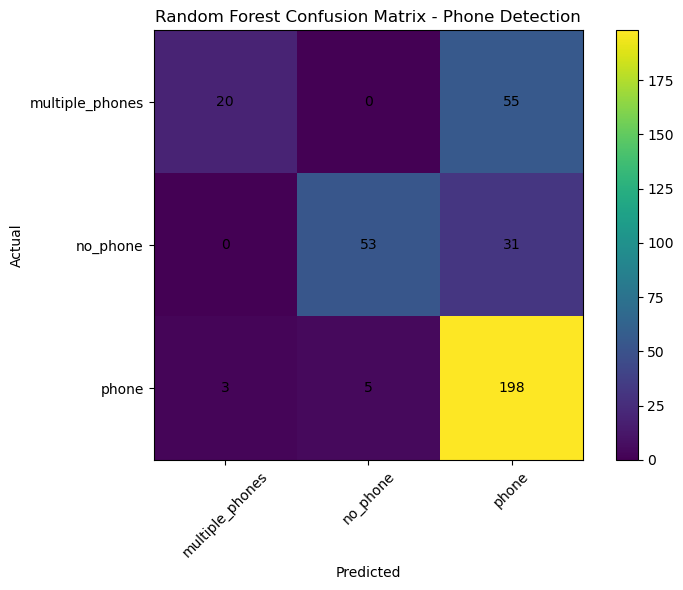

Confusion matrix saved to: C:\Users\user\Desktop\Smartphone_AI_Project\models\phone_detection_ml\confusion_matrix_random_forest.png


In [12]:
cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Random Forest Confusion Matrix - Phone Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45)
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH)
plt.show()

print("Confusion matrix saved to:", CONFUSION_MATRIX_PATH)

In [13]:
joblib.dump(rf_model, MODEL_PATH)

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(CLASS_NAMES, f)

print("Model saved to:", MODEL_PATH)
print("Class names saved to:", CLASS_NAMES_PATH)

Model saved to: C:\Users\user\Desktop\Smartphone_AI_Project\models\phone_detection_ml\random_forest_phone_detection.pkl
Class names saved to: C:\Users\user\Desktop\Smartphone_AI_Project\models\phone_detection_ml\class_names.json


In [14]:
def predict_one_image(image_path):
    features = preprocess_image(image_path)
    features = features.reshape(1, -1)

    prediction_index = rf_model.predict(features)[0]
    probabilities = rf_model.predict_proba(features)[0]

    predicted_class = CLASS_NAMES[prediction_index]
    confidence = probabilities[prediction_index]

    print("Image:", image_path)
    print("Prediction:", predicted_class)
    print("Confidence:", round(confidence * 100, 2), "%")

    print("\nAll probabilities:")
    for class_name, prob in zip(CLASS_NAMES, probabilities):
        print(class_name, ":", round(prob * 100, 2), "%")

    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class} ({confidence*100:.2f}%)")
    plt.show()